# 🌤️ Heat-Safe Bangladesh: An Air Quality and Weather-Based Outdoor Activity Planner

**An entry-level data science project**

Bangladesh — and Dhaka in particular — regularly experiences very high levels of air pollution combined with hot,
humid weather. This notebook builds a simple, beginner-friendly pipeline that:

1. Cleans and explores several years of hourly air-quality and weather data,
2. Engineers a few practical features (time-of-day, temperature/humidity categories, pollution spikes, etc.),
3. Defines a transparent, rule-based **Outdoor Risk** category (Low / Moderate / High / Extreme) for outdoor planning,
4. Trains simple machine-learning models that try to **forecast the next recorded period's AQI severity**, and
5. Summarizes practical, general outdoor-planning guidance.

> ⚠️ **Disclaimer:** Everything produced here is *general outdoor-planning guidance* based on historical statistical
> patterns. It is **not medical advice**. People with asthma, heart or lung conditions, children, older adults, and
> pregnant people should follow guidance from a doctor or official health authority, especially during poor air
> quality days.

---
## 0. About the dataset

The dataset contains hourly measurements of common air pollutants (SO2, NO, NO2, NOX, CO, O3, PM2.5, PM10),
weather variables (Temperature, Relative Humidity, Solar Radiation), a computed Air Quality Index (`AQI`) and its
category (`AQI_severity`), for several cities across Bangladesh between **November 2012 and December 2020**.

We will inspect the raw file first, then make deliberate, explained decisions about how to clean it.

## 1. Import libraries and load the dataset

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

### Loading the file

On Kaggle, an attached dataset is mounted under `/kaggle/input/<dataset-name>/...`. The cell below looks in the
most common locations so the notebook runs both on Kaggle and locally without edits. If your dataset lives
somewhere else, just update `CSV_PATH`.

In [2]:
CANDIDATE_PATHS = [
    "cleaned_AQI.csv",
    "/kaggle/input/cleaned-aqi/cleaned_AQI.csv",
    "/kaggle/input/cleaned_aqi/cleaned_AQI.csv",
    "/kaggle/input/heat-safe-bangladesh/cleaned_AQI.csv",
]

CSV_PATH = None
for p in CANDIDATE_PATHS:
    if os.path.exists(p):
        CSV_PATH = p
        break

if CSV_PATH is None:
    # fall back: search /kaggle/input for any file named cleaned_AQI.csv
    for root, _dirs, files in os.walk("/kaggle/input"):
        if "cleaned_AQI.csv" in files:
            CSV_PATH = os.path.join(root, "cleaned_AQI.csv")
            break

assert CSV_PATH is not None, "Could not find cleaned_AQI.csv — set CSV_PATH manually."
print("Loading dataset from:", CSV_PATH)

df_raw = pd.read_csv(CSV_PATH)
print("Loaded successfully.")

Loading dataset from: cleaned_AQI.csv


Loaded successfully.


## 2. Inspect the raw dataset

In [3]:
print("Shape (rows, columns):", df_raw.shape)

Shape (rows, columns): (592748, 18)


In [4]:
print("Column names:")
print(df_raw.columns.tolist())

Column names:
['Date', 'Time', 'SO2', 'NO', 'NO2', 'NOX', 'CO', 'O3', 'PM2.5', 'PM10', 'Temperature', 'RH', 'Solar Rad', 'Month', 'Day', 'AQI', 'AQI_severity', 'Location']


In [5]:
print("Data types:")
print(df_raw.dtypes)

Data types:
Date                str
Time                str
SO2             float64
NO              float64
NO2             float64
NOX             float64
CO              float64
O3              float64
PM2.5           float64
PM10            float64
Temperature     float64
RH              float64
Solar Rad       float64
Month           float64
Day             float64
AQI             float64
AQI_severity        str
Location            str
dtype: object


In [6]:
print("Descriptive statistics (numeric columns):")
df_raw.describe().T

Descriptive statistics (numeric columns):


,count,mean,std,min,25%,50%,75%,max
SO2,592748.0,6.530921,13.209102,-0.340000,2.140000,3.540000,6.340000,299.94
NO,592748.0,18.056319,34.504462,-12.640000,3.090000,6.240000,19.295000,590.31
NO2,592748.0,14.121151,16.376954,0.000000,5.360000,9.940000,16.180000,399.47
NOX,592748.0,29.890021,41.932617,0.000000,8.910000,17.250000,29.870000,653.67
CO,592748.0,1.351559,1.553004,0.000000,0.610000,0.940000,1.640000,79.81
O3,592748.0,7.792850,10.790835,0.000000,2.010000,4.690000,8.530000,149.42
PM2.5,592748.0,73.719882,67.994043,0.000000,31.820000,54.230000,89.370000,1072.20
PM10,592748.0,130.115702,112.976401,-14.030000,63.790000,102.880000,158.470000,1354.82
Temperature,592748.0,25.384932,4.934506,-9.200000,23.358230,25.960000,27.781710,1022.80
RH,592748.0,74.069985,18.641907,3.560000,66.230000,77.589267,84.678773,6813.75


In [7]:
print("Missing values per column:")
print(df_raw.isna().sum())

Missing values per column:
Date            0
Time            0
SO2             0
NO              0
NO2             0
NOX             0
CO              0
O3              0
PM2.5           0
PM10            0
Temperature     0
RH              0
Solar Rad       0
Month           0
Day             0
AQI             0
AQI_severity    0
Location        0
dtype: int64


In [8]:
print("Fully duplicated rows:", df_raw.duplicated().sum())

Fully duplicated rows: 0


### A closer look before cleaning

Two things stand out immediately and will shape our cleaning decisions:

1. There is a **`Location`** column (not mentioned in the task brief) with **12 different Bangladeshi cities**.
2. The **`Time`** column is stored as text and, for some cities, contains messy values (spreadsheet export
   artifacts such as `'1900-01-18 00:00:00'` instead of a clean `HH:MM`).

In [9]:
print(df_raw["Location"].value_counts())

Location
Dhaka          171450
Rajshahi        65050
Barishal        62801
Narayonganj     61344
Gazipur         59707
Sylhet          59243
Khulna          45675
Chittagong      41270
Rangpur          8048
Narsingdi        7869
Cumilla          5358
Mymansingh       4933
Name: count, dtype: int64


In [10]:
messy_time_mask = ~df_raw["Time"].astype(str).str.match(r"^\d{2}:\d{2}$")
print("Rows with a non-standard 'Time' value:", messy_time_mask.sum())
print(df_raw.loc[messy_time_mask, "Time"].value_counts().head(10))

Rows with a non-standard 'Time' value: 7743
Time
1900-01-02 00:00:00    326
1900-01-03 00:00:00    326
1900-01-04 00:00:00    326
1900-01-05 00:00:00    326
1900-01-21 00:00:00    325
1900-01-01 00:00:00    325
1900-01-23 00:00:00    324
1900-01-24 00:00:00    324
1900-01-06 00:00:00    324
1900-01-07 00:00:00    324
Name: count, dtype: int64


**Decision:** To keep this *entry-level* project focused and to avoid mixing multiple independent time series
(which would complicate lag/rolling features and chronological train/test splitting), we will build the full
analysis around **Dhaka** — the capital, the most heavily monitored city, and the city with the longest, most
complete hourly record (2012–2020). The exact same pipeline could be re-run for any other city, or extended into
a multi-city model later — we call this out explicitly as a natural next step.

We also confirm above that Dhaka's own `Time` column is already in a clean `HH:MM` format, so we don't need to
fix the messy spreadsheet-artifact rows for the city we're studying (they belong to other cities).

## 3. Clean and preprocess the data

### 3.1 Strip column names and standardize numeric types

In [11]:
df = df_raw.copy()
df.columns = df.columns.str.strip()

pollutant_cols = ["SO2", "NO", "NO2", "NOX", "CO", "O3", "PM2.5", "PM10"]
weather_cols = ["Temperature", "RH", "Solar Rad"]
numeric_cols = pollutant_cols + weather_cols + ["Month", "Day", "AQI"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Non-numeric values introduced as NaN by coercion:")
print(df[numeric_cols].isna().sum())

Non-numeric values introduced as NaN by coercion:
SO2            0
NO             0
NO2            0
NOX            0
CO             0
O3             0
PM2.5          0
PM10           0
Temperature    0
RH             0
Solar Rad      0
Month          0
Day            0
AQI            0
dtype: int64


### 3.2 Focus on Dhaka

In [12]:
df = df[df["Location"] == "Dhaka"].copy()
print("Dhaka-only shape:", df.shape)

Dhaka-only shape: (171450, 18)


### 3.3 Combine `Date` and `Time` into `DateTime`

`Time` uses `'24:00'` for the last hour of the day in some rows — that actually means *midnight of the next day*,
so we roll those rows forward by one day before combining.

In [13]:
is_midnight_24 = df["Time"].astype(str).str.strip() == "24:00"
print("Rows using the '24:00' convention:", is_midnight_24.sum())

time_clean = df["Time"].astype(str).str.strip().replace({"24:00": "00:00"})
date_part = pd.to_datetime(df["Date"], format="mixed").dt.normalize()
date_part.loc[is_midnight_24] = date_part.loc[is_midnight_24] + pd.Timedelta(days=1)

df["DateTime"] = pd.to_datetime(
    date_part.dt.strftime("%Y-%m-%d") + " " + time_clean, errors="coerce"
)
print("Rows where DateTime failed to parse:", df["DateTime"].isna().sum())

Rows using the '24:00' convention: 7150
Rows where DateTime failed to parse: 0


### 3.4 Handle duplicate timestamps

Grouping by `DateTime` reveals that most hours actually appear **two, three, or more times** — almost certainly
because several monitoring stations inside Dhaka were merged into one city-level file without a station ID. There
is no reliable way to tell the stations apart, so the simplest, most transparent fix is to **average all
numeric readings that share the same timestamp**, producing one clean hourly value per pollutant/weather variable.

In [14]:
dup_counts = df.groupby("DateTime").size()
print(dup_counts.value_counts().sort_index())

rows_before = len(df)
df = df.groupby("DateTime", as_index=False)[numeric_cols].mean()
print(f"Rows before averaging: {rows_before:,} -> after averaging: {len(df):,}")

1     3702
2    32277
3    30034
4      692
5     1286
6      649
Name: count, dtype: int64
Rows before averaging: 171,450 -> after averaging: 68,640


### 3.5 Handle implausible values and missing data

A quick sanity check on physically-plausible ranges (pollutant concentrations can't be negative; Dhaka's
historical hourly temperature realistically sits well within 5–45 °C; relative humidity can't exceed 100%) flags a
small number of clearly bad sensor readings. We convert those to missing values and then fill short gaps with
linear interpolation along the (now chronologically sorted) time axis — a very common, easy-to-explain approach
for hourly sensor data.

In [15]:
print("Negative SO2 readings:", (df["SO2"] < 0).sum())
print("Temperature outside 5-45°C:", ((df["Temperature"] < 5) | (df["Temperature"] > 45)).sum())
print("RH above 100%:", (df["RH"] > 100).sum())

df.loc[df["SO2"] < 0, "SO2"] = np.nan
df.loc[(df["Temperature"] < 5) | (df["Temperature"] > 45), "Temperature"] = np.nan
df.loc[df["RH"] > 100, "RH"] = 100.0

df = df.sort_values("DateTime").reset_index(drop=True)
df[numeric_cols] = df[numeric_cols].interpolate(method="linear", limit_direction="both")

print("\nRemaining missing values after interpolation:")
print(df[numeric_cols].isna().sum())

Negative SO2 readings: 0
Temperature outside 5-45°C: 3
RH above 100%: 1

Remaining missing values after interpolation:
SO2            0
NO             0
NO2            0
NOX            0
CO             0
O3             0
PM2.5          0
PM10           0
Temperature    0
RH             0
Solar Rad      0
Month          0
Day            0
AQI            0
dtype: int64


### 3.6 Recompute `AQI_severity` from the cleaned `AQI`

Since we averaged multiple sensor readings, we recompute `AQI_severity` directly from the (now averaged) `AQI`
value, using the standard EPA-style breakpoints that this dataset's original labels also follow (confirmed by
checking the min/max AQI within each original severity label): Good 0–50, Moderate 51–100, Unhealthy for
Sensitive Groups 101–150, Unhealthy 151–200, Very Unhealthy 201–300, Hazardous 301+.

In [16]:
def aqi_to_severity(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Moderate"
    elif aqi <= 150:
        return "Unhealthy for Sensitive Groups"
    elif aqi <= 200:
        return "Unhealthy"
    elif aqi <= 300:
        return "Very Unhealthy"
    else:
        return "Hazardous"

df["AQI_severity"] = df["AQI"].apply(aqi_to_severity)
print(df["AQI_severity"].value_counts())

AQI_severity
Moderate                          20675
Unhealthy for Sensitive Groups    18826
Unhealthy                         15226
Very Unhealthy                     8032
Good                               4204
Hazardous                          1677
Name: count, dtype: int64


### 3.7 Extract `Year`, `Hour`, `Month`, `Day`, `Day_of_week`

In [17]:
df["Year"] = df["DateTime"].dt.year
df["Month"] = df["DateTime"].dt.month
df["Day"] = df["DateTime"].dt.day
df["Hour"] = df["DateTime"].dt.hour
df["Day_of_week"] = df["DateTime"].dt.day_name()

df = df[
    ["DateTime", "Year", "Month", "Day", "Hour", "Day_of_week"] + pollutant_cols + weather_cols + ["AQI", "AQI_severity"]
]
df.head()

,DateTime,Year,Month,Day,Hour,Day_of_week,SO2,NO,NO2,NOX,CO,O3,PM2.5,PM10,Temperature,RH,Solar Rad,AQI,AQI_severity
0,2012-11-01 01:00:00,2012,11,1,1,Thursday,5.87,2.98,32.91,35.90,1.20,3.66,93.45,113.85,27.50,77.78,7.76,170.594837,Unhealthy
1,2012-11-01 02:00:00,2012,11,1,2,Thursday,5.87,23.64,34.91,58.55,1.14,3.17,73.61,108.25,27.39,77.38,7.64,160.350790,Unhealthy
2,2012-11-01 03:00:00,2012,11,1,3,Thursday,0.29,40.71,34.84,75.55,1.20,3.23,60.27,85.49,26.60,81.52,7.71,153.462908,Unhealthy
3,2012-11-01 04:00:00,2012,11,1,4,Thursday,0.94,78.05,33.78,112.34,1.30,3.28,70.64,101.54,26.06,83.04,7.63,158.817281,Unhealthy
4,2012-11-01 05:00:00,2012,11,1,5,Thursday,0.47,63.62,31.90,95.74,1.15,3.26,90.43,117.05,25.75,83.75,7.57,169.035511,Unhealthy


### 3.8 A note on measurement units

Before interpreting the numbers, it's worth being explicit about the units we're assuming (the raw file doesn't
state them, so we go with the conventional units used in air-quality reporting):

| Column | Assumed unit |
|---|---|
| SO2, NO, NO2, NOX, O3, PM2.5, PM10 | µg/m³ |
| CO | mg/m³ |
| Temperature | °C |
| RH (Relative Humidity) | % |
| Solar Rad | W/m² |
| AQI | Unitless index (EPA-style, 0–500 scale) |

### 3.9 Final checks

In [18]:
print("Final shape:", df.shape)
print("Remaining missing values:", df.isna().sum().sum())
print("Duplicate DateTime rows:", df["DateTime"].duplicated().sum())
print("Date range:", df["DateTime"].min(), "to", df["DateTime"].max())

expected_hours = pd.date_range(df["DateTime"].min(), df["DateTime"].max(), freq="h")
coverage = len(df) / len(expected_hours)
print(f"Hourly coverage: {len(df):,} / {len(expected_hours):,} possible hours ({coverage:.1%})")

Final shape: (68640, 19)
Remaining missing values: 0
Duplicate DateTime rows: 0
Date range: 2012-11-01 01:00:00 to 2021-01-01 00:00:00
Hourly coverage: 68,640 / 71,592 possible hours (95.9%)


We have a clean, gap-tolerant hourly series for Dhaka (~96% hourly coverage — a few short gaps remain, which is
normal for real sensor data and is why later we'll describe our ML target as the "next **recorded** period"
rather than assuming exactly one hour).

## 4. Exploratory Data Analysis

### 4.1 During which hours is AQI lowest and highest?

Lowest average AQI hours:
Hour
17    113.980935
16    115.462233
18    116.206241
Name: AQI, dtype: float64

Highest average AQI hours:
Hour
0     144.885587
23    146.793016
22    146.884347
Name: AQI, dtype: float64


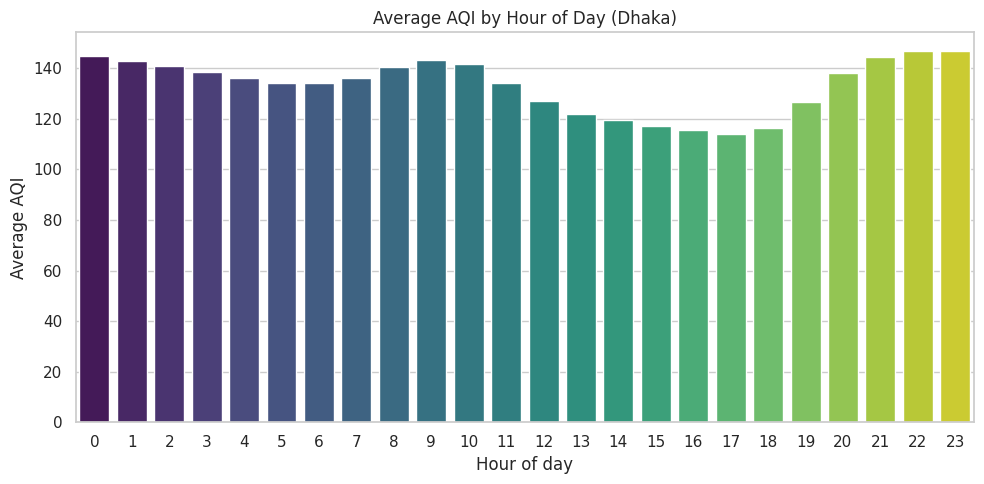

In [19]:
hourly_aqi = df.groupby("Hour")["AQI"].mean().sort_values()
print("Lowest average AQI hours:")
print(hourly_aqi.head(3))
print("\nHighest average AQI hours:")
print(hourly_aqi.tail(3))

fig, ax = plt.subplots(figsize=(10, 5))
order = df.groupby("Hour")["AQI"].mean().sort_index()
sns.barplot(x=order.index, y=order.values, ax=ax, palette="viridis")
ax.set_title("Average AQI by Hour of Day (Dhaka)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Average AQI")
plt.tight_layout()
plt.show()

### 4.2 Which months have the poorest air quality?

Month
8      77.677176
7      85.506175
6      96.576743
9      97.826545
5     105.048741
10    116.807213
4     128.258562
11    156.094241
3     157.413565
12    184.999688
2     191.563061
1     213.085074
Name: AQI, dtype: float64


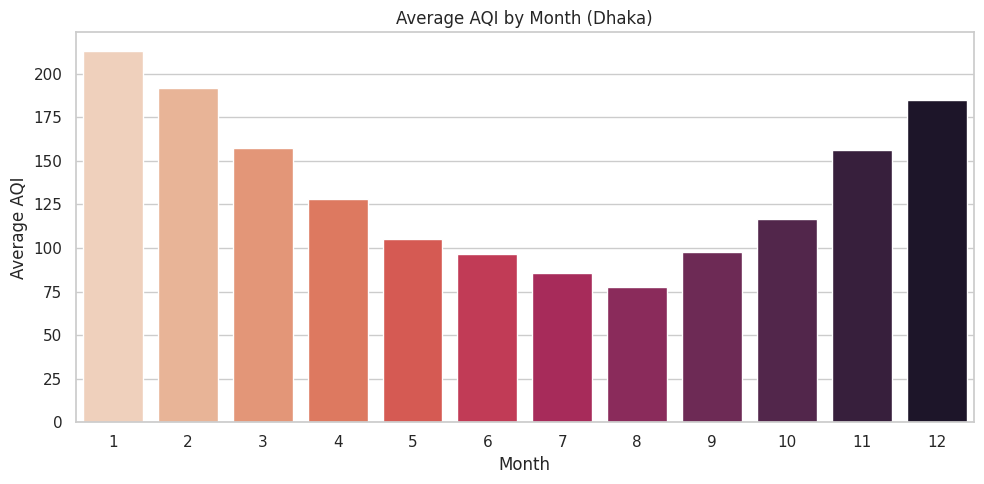

In [20]:
monthly_aqi = df.groupby("Month")["AQI"].mean().sort_values()
print(monthly_aqi)

fig, ax = plt.subplots(figsize=(10, 5))
order = df.groupby("Month")["AQI"].mean().sort_index()
colors = sns.color_palette("rocket_r", 12)
sns.barplot(x=order.index, y=order.values, ax=ax, palette=colors)
ax.set_title("Average AQI by Month (Dhaka)")
ax.set_xlabel("Month")
ax.set_ylabel("Average AQI")
plt.tight_layout()
plt.show()

**Pattern:** Air quality is clearly seasonal — Bangladesh's dry winter months (December–February) show the worst
AQI, while the monsoon months (June–September) are considerably cleaner, most likely because rain washes
particulate matter out of the air.

### 4.3 How do temperature, humidity and solar radiation affect AQI?

Temperature   -0.435984
RH            -0.180285
Solar Rad     -0.087572
Name: AQI, dtype: float64


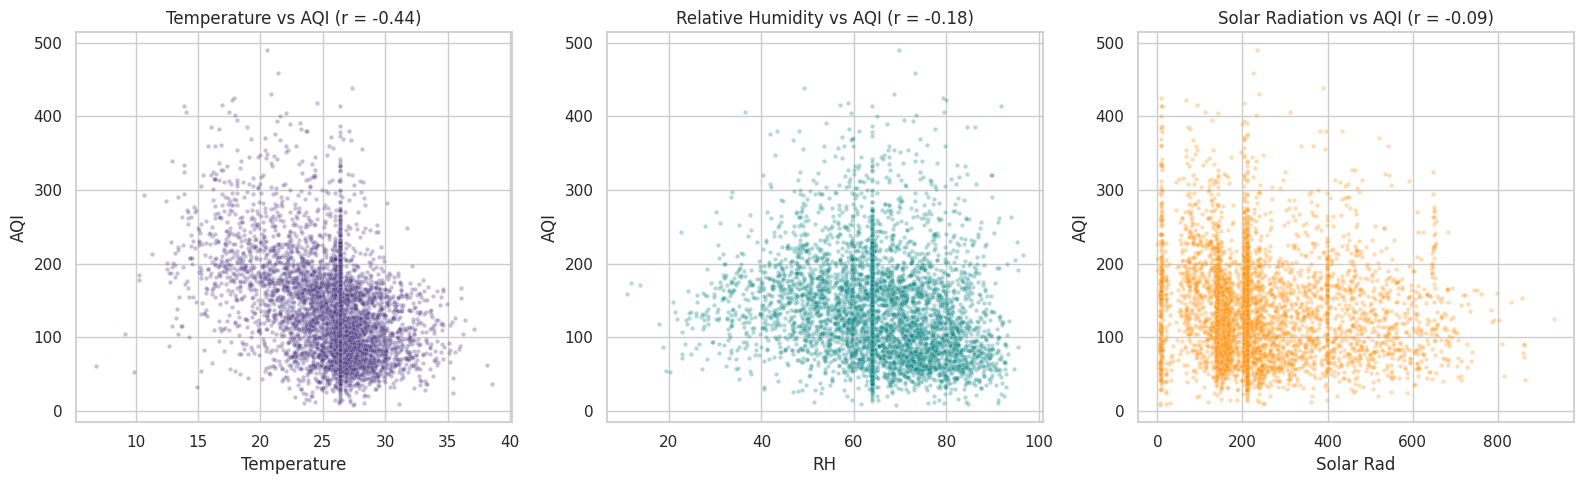

In [21]:
weather_corr = df[["Temperature", "RH", "Solar Rad", "AQI"]].corr()["AQI"].drop("AQI")
print(weather_corr)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
sns.scatterplot(data=df.sample(5000, random_state=RANDOM_STATE), x="Temperature", y="AQI", ax=axes[0], alpha=0.3, s=10)
axes[0].set_title(f"Temperature vs AQI (r = {weather_corr['Temperature']:.2f})")
sns.scatterplot(data=df.sample(5000, random_state=RANDOM_STATE), x="RH", y="AQI", ax=axes[1], alpha=0.3, s=10, color="teal")
axes[1].set_title(f"Relative Humidity vs AQI (r = {weather_corr['RH']:.2f})")
sns.scatterplot(data=df.sample(5000, random_state=RANDOM_STATE), x="Solar Rad", y="AQI", ax=axes[2], alpha=0.3, s=10, color="darkorange")
axes[2].set_title(f"Solar Radiation vs AQI (r = {weather_corr['Solar Rad']:.2f})")
plt.tight_layout()
plt.show()

**Interpretation:** AQI tends to be **lower on warmer, more humid, sunnier hours/days** — this fits the seasonal
story above: Dhaka's cooler, drier winter is also its most polluted season, while the warm, humid monsoon brings
cleaner air. This is a *correlation*, not proof that temperature itself "causes" cleaner air — the shared driver
is the season/weather pattern (monsoon rain, wind, and mixing conditions).

### 4.4 Which pollutants have the strongest relationship with AQI?

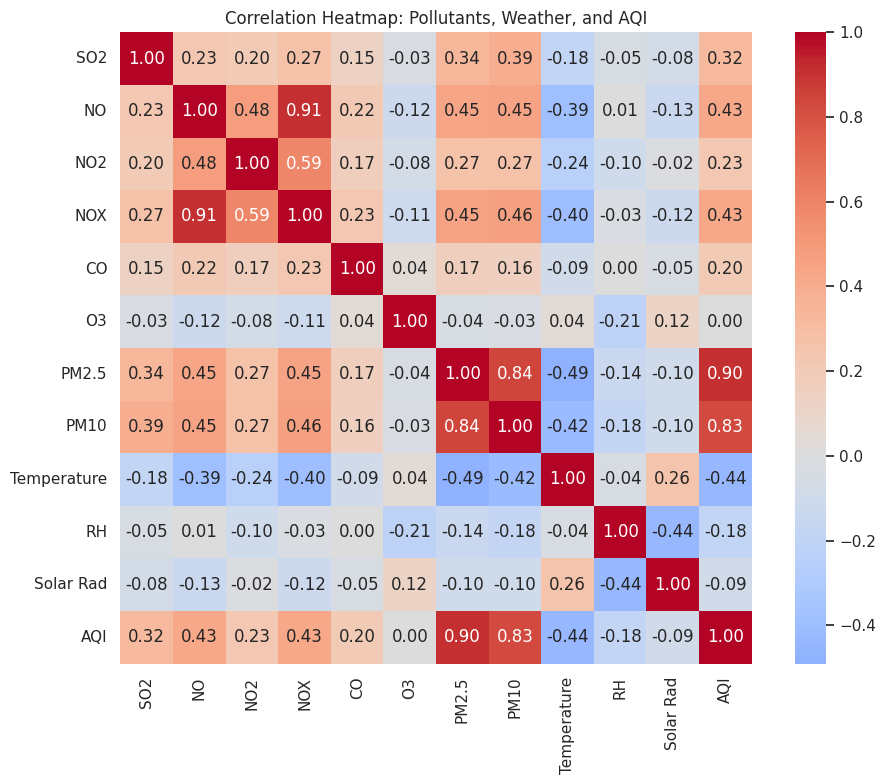

PM2.5          0.904894
PM10           0.827518
NOX            0.426443
NO             0.425952
SO2            0.316569
NO2            0.232318
CO             0.201878
O3             0.000998
Solar Rad     -0.087572
RH            -0.180285
Temperature   -0.435984
Name: AQI, dtype: float64


In [22]:
corr_cols = pollutant_cols + weather_cols + ["AQI"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlation Heatmap: Pollutants, Weather, and AQI")
plt.tight_layout()
plt.show()

print(corr_matrix["AQI"].drop("AQI").sort_values(ascending=False))

**Finding:** `PM2.5` and `PM10` (fine and coarse particulate matter) have, by far, the strongest relationship
with AQI — which makes sense, since particulate matter is usually the pollutant that determines Dhaka's AQI value
on most days. `NOX` and `NO` (traffic-related gases) come next, while `O3` shows almost no linear relationship.

### 4.5 Pollutant distributions

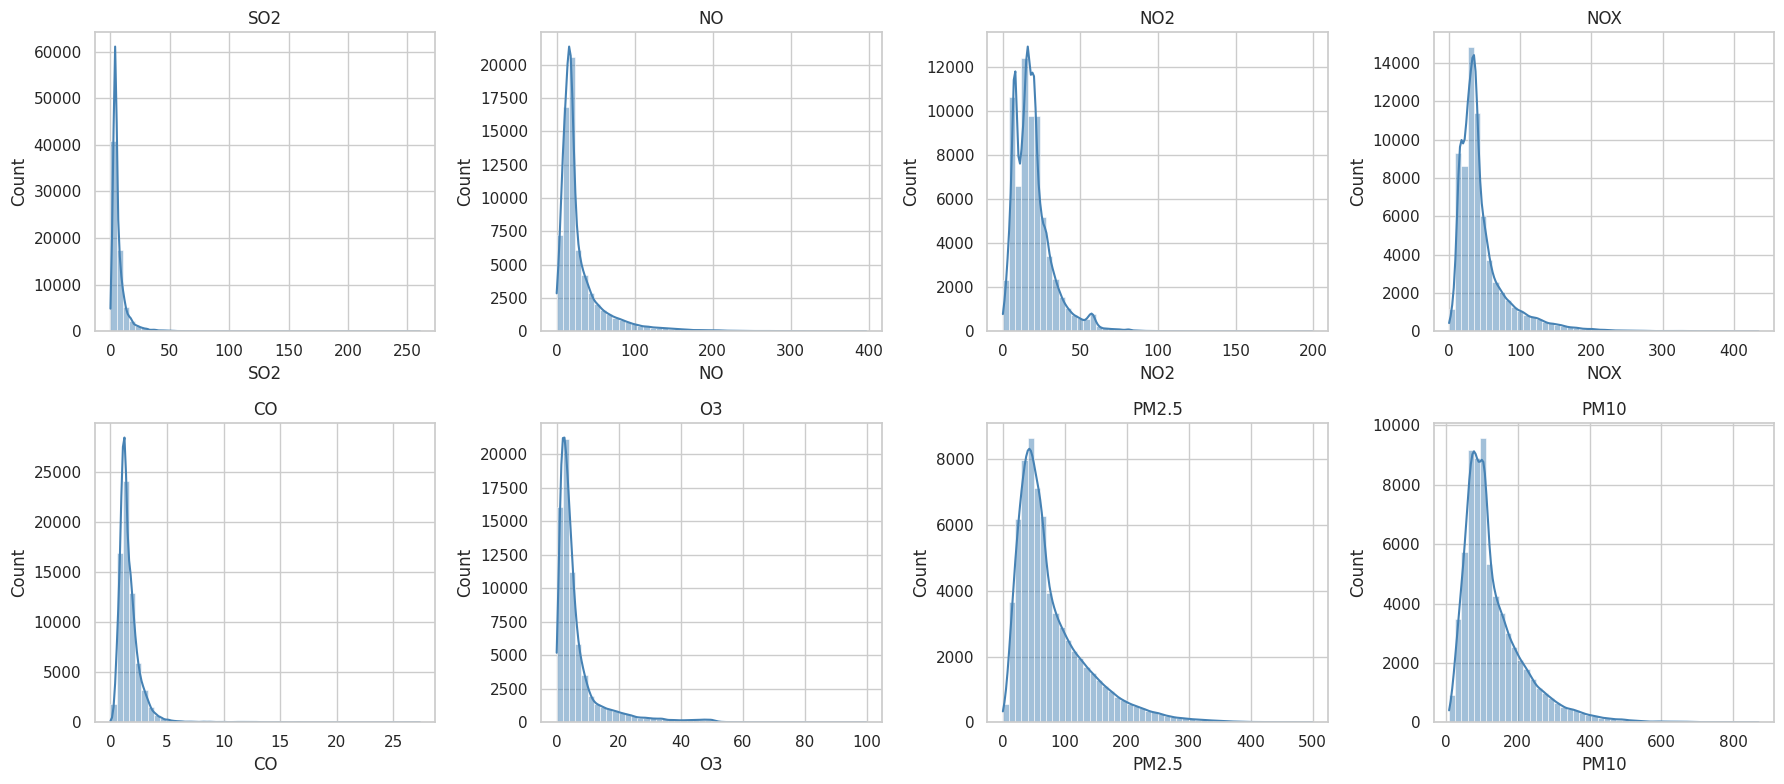

In [23]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flatten(), pollutant_cols):
    sns.histplot(df[col], bins=50, kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

Most pollutants are right-skewed (a long tail of occasional high-pollution hours), which is typical of air-quality
data — this is also why, later on, tree-based models (which don't assume any particular distribution shape) tend
to work well for this kind of data.

### 4.6 AQI severity distribution

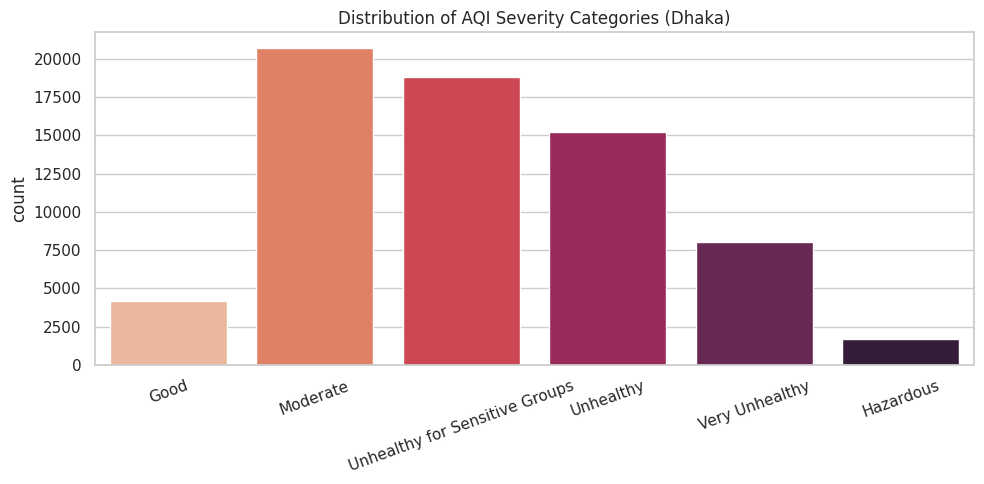

AQI_severity
Moderate                          30.1
Unhealthy for Sensitive Groups    27.4
Unhealthy                         22.2
Very Unhealthy                    11.7
Good                               6.1
Hazardous                          2.4
Name: proportion, dtype: float64


In [24]:
severity_order = ["Good", "Moderate", "Unhealthy for Sensitive Groups", "Unhealthy", "Very Unhealthy", "Hazardous"]

fig, ax = plt.subplots(figsize=(10, 5))
sns.countplot(data=df, x="AQI_severity", order=severity_order, palette="rocket_r", ax=ax)
ax.set_title("Distribution of AQI Severity Categories (Dhaka)")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print((df["AQI_severity"].value_counts(normalize=True) * 100).round(1))

### 4.7 How does AQI severity change throughout the day?

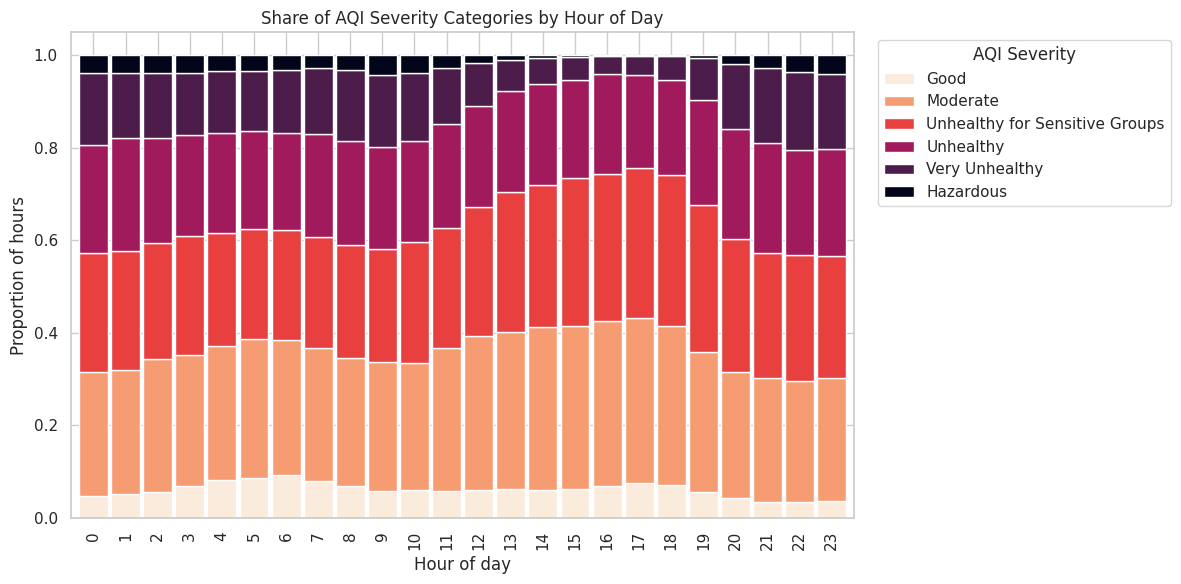

In [25]:
hour_severity = pd.crosstab(df["Hour"], df["AQI_severity"], normalize="index")[severity_order]

fig, ax = plt.subplots(figsize=(12, 6))
hour_severity.plot(kind="bar", stacked=True, ax=ax, colormap="rocket_r", width=0.9)
ax.set_title("Share of AQI Severity Categories by Hour of Day")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Proportion of hours")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="AQI Severity")
plt.tight_layout()
plt.show()

### 4.8 Unusual pollution spikes and extreme-weather periods

In [26]:
aqi_q99 = df["AQI"].quantile(0.99)
spikes = df[df["AQI"] > aqi_q99]
print(f"AQI 99th percentile threshold: {aqi_q99:.1f}")
print(f"Number of extreme-pollution hours: {len(spikes)}")
print("Spikes by month:")
print(spikes["Month"].value_counts().sort_index())

extreme_hot = df[df["Temperature"] > df["Temperature"].quantile(0.99)]
print(f"\nExtreme-heat hours (>99th pct, {df['Temperature'].quantile(0.99):.1f}°C): {len(extreme_hot)}")

AQI 99th percentile threshold: 342.8
Number of extreme-pollution hours: 687
Spikes by month:
Month
1     283
2     193
3      61
4      19
9       1
10      8
11     51
12     71
Name: count, dtype: int64

Extreme-heat hours (>99th pct, 33.8°C): 686


### 4.9 AQI trend over time

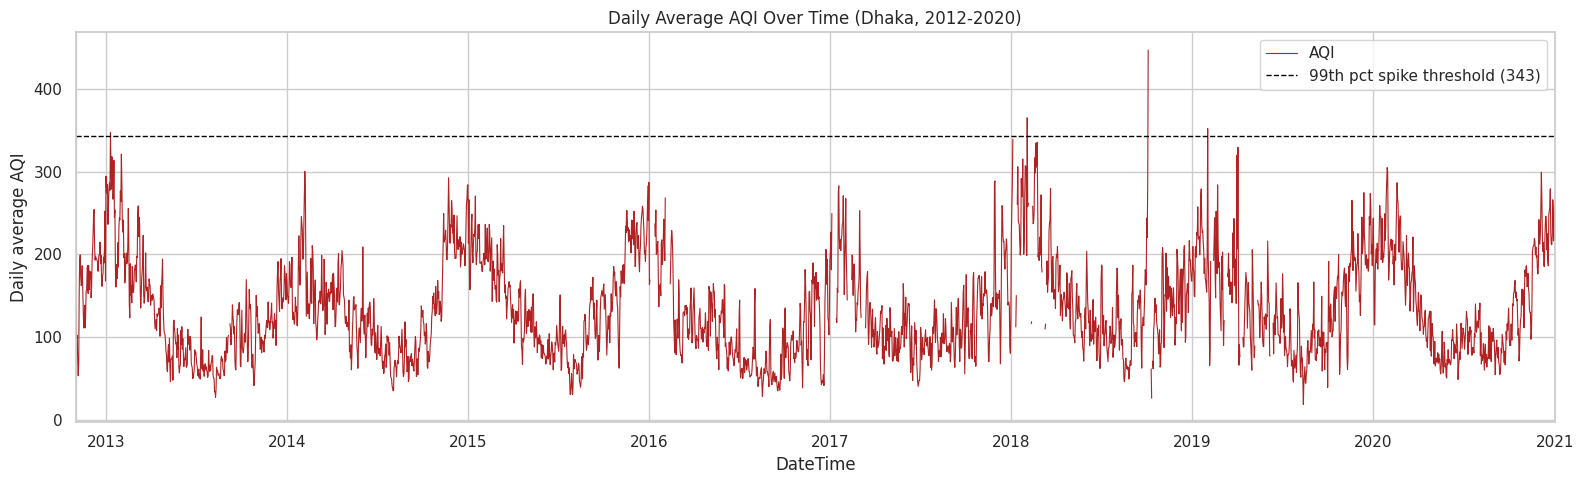

In [27]:
daily_aqi = df.set_index("DateTime")["AQI"].resample("D").mean()

fig, ax = plt.subplots(figsize=(16, 5))
daily_aqi.plot(ax=ax, color="firebrick", linewidth=0.8)
ax.axhline(aqi_q99, color="black", linestyle="--", linewidth=1, label=f"99th pct spike threshold ({aqi_q99:.0f})")
ax.set_title("Daily Average AQI Over Time (Dhaka, 2012-2020)")
ax.set_ylabel("Daily average AQI")
ax.legend()
plt.tight_layout()
plt.show()

### 4.10 Hour-by-month AQI heatmap

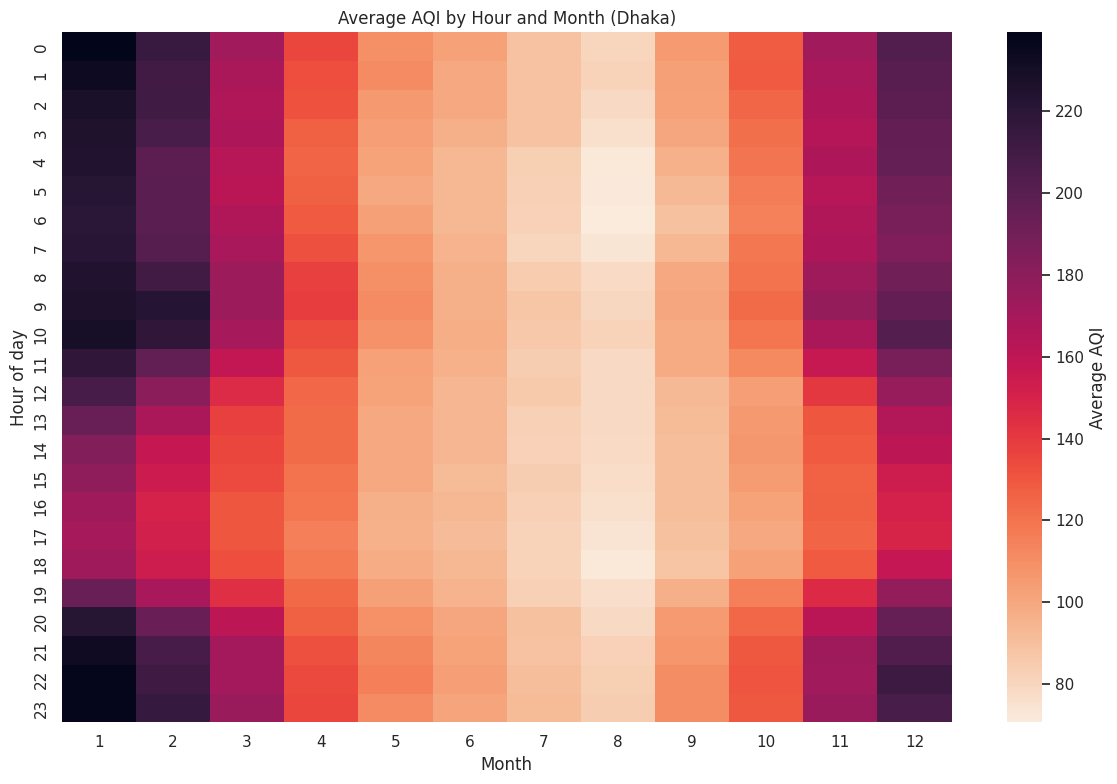

In [28]:
pivot = df.pivot_table(index="Hour", columns="Month", values="AQI", aggfunc="mean")

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot, cmap="rocket_r", ax=ax, cbar_kws={"label": "Average AQI"})
ax.set_title("Average AQI by Hour and Month (Dhaka)")
ax.set_xlabel("Month")
ax.set_ylabel("Hour of day")
plt.tight_layout()
plt.show()

**Key EDA takeaways:**
- Air quality is **worst in the early-to-mid morning hours** and generally **better in the late afternoon/evening**.
- **Winter months (Nov–Feb)** are by far the worst for air quality; **monsoon months (Jun–Sep)** are the cleanest.
- **PM2.5 and PM10** dominate the AQI signal; traffic-related gases (NO, NOX) matter next.
- Warmer, more humid, sunnier conditions coincide with cleaner air (a seasonal effect, not necessarily causal).

## 5. Feature Engineering

We now build a handful of simple, interpretable features that will be useful both for understanding outdoor
safety patterns and for the machine-learning models later.

In [29]:
df = df.sort_values("DateTime").reset_index(drop=True)

# Time-based features (Hour, Year, Month, Day already extracted in section 3.7)
df["Is_weekend"] = df["Day_of_week"].isin(["Friday", "Saturday"]).astype(int)  # Bangladesh weekend is Fri-Sat

# Temperature category
def temperature_category(t):
    if t < 20:
        return "Cool"
    elif t < 26:
        return "Mild"
    elif t < 32:
        return "Warm"
    else:
        return "Hot"

df["Temp_category"] = df["Temperature"].apply(temperature_category)

# Humidity category
def humidity_category(h):
    if h < 40:
        return "Low"
    elif h < 60:
        return "Moderate"
    elif h < 80:
        return "High"
    else:
        return "Very High"

df["Humidity_category"] = df["RH"].apply(humidity_category)

# Pollution spike indicator: PM2.5 above its own 90th percentile
pm25_spike_threshold = df["PM2.5"].quantile(0.90)
df["Pollution_spike"] = (df["PM2.5"] > pm25_spike_threshold).astype(int)

# Previous-hour AQI and rolling average AQI (both look only at PAST rows, never the current one)
df["Prev_AQI"] = df["AQI"].shift(1)
df["Rolling_AQI_24h"] = df["AQI"].shift(1).rolling(window=24, min_periods=6).mean()

print("New feature columns added:")
print(df[["Hour", "Year", "Day_of_week", "Is_weekend", "Temp_category",
          "Humidity_category", "Pollution_spike", "Prev_AQI", "Rolling_AQI_24h"]].head(8))

print(f"\nPM2.5 spike threshold (90th percentile): {pm25_spike_threshold:.1f} µg/m³")
print(f"Share of hours flagged as pollution spikes: {df['Pollution_spike'].mean():.1%}")

New feature columns added:
   Hour  Year Day_of_week  Is_weekend Temp_category Humidity_category  \
0     1  2012    Thursday           0          Warm              High   
1     2  2012    Thursday           0          Warm              High   
2     3  2012    Thursday           0          Warm         Very High   
3     4  2012    Thursday           0          Warm         Very High   
4     5  2012    Thursday           0          Mild         Very High   
5     6  2012    Thursday           0          Mild         Very High   
6     7  2012    Thursday           0          Mild         Very High   
7     8  2012    Thursday           0          Warm              High   

   Pollution_spike    Prev_AQI  Rolling_AQI_24h  
0                0         NaN              NaN  
1                0  170.594837              NaN  
2                0  160.350790              NaN  
3                0  153.462908              NaN  
4                0  158.817281              NaN  
5              

> **Note on `Rolling_AQI_24h`:** the rolling window is computed on `AQI.shift(1)`, i.e. it only ever looks at the
> *previous* 24 recorded hours — the current row's own AQI value is deliberately excluded. This keeps the feature
> usable later for genuine "next-period" forecasting without leaking the very value we're trying to predict.

## 6. Outdoor Risk Classification

We combine **AQI severity** with simple **weather stress factors** into one easy-to-read `Outdoor_Risk` label:
`Low`, `Moderate`, `High`, or `Extreme`.

**Rules (transparent and rule-based, not a statistical model):**

1. Start from a numeric **severity score** based on `AQI_severity`:
   `Good=0, Moderate=1, Unhealthy for Sensitive Groups=2, Unhealthy=3, Very Unhealthy=4, Hazardous=5`.
2. Add a **weather penalty** (0 to 3 points), one point for each of:
   - Temperature category is `Hot` (≥ 32°C),
   - Humidity category is `High` or `Very High` (≥ 60% RH),
   - Solar radiation is above its 75th percentile (strong midday sun).
3. Add the severity score and the weather penalty into a single `risk_score` (0–8), then bucket it:
   - `risk_score` 0–1 → **Low**
   - `risk_score` 2–3 → **Moderate**
   - `risk_score` 4–5 → **High**
   - `risk_score` 6–8 → **Extreme**

This is intentionally simple: it lets air quality dominate the rating (since that's the biggest known health
stressor) while still nudging the category upward on hot, humid, or high-sun-exposure hours, which add heat
stress on top of poor air quality.

> **This is general outdoor-planning guidance only, not medical advice.** People with respiratory or heart
> conditions, older adults, children, and pregnant people should be more cautious than these general categories
> suggest, and should consult a doctor or local health authority for personal guidance.

Outdoor_Risk
Low          4508
Moderate    40041
High        22394
Extreme      1697
Name: count, dtype: int64


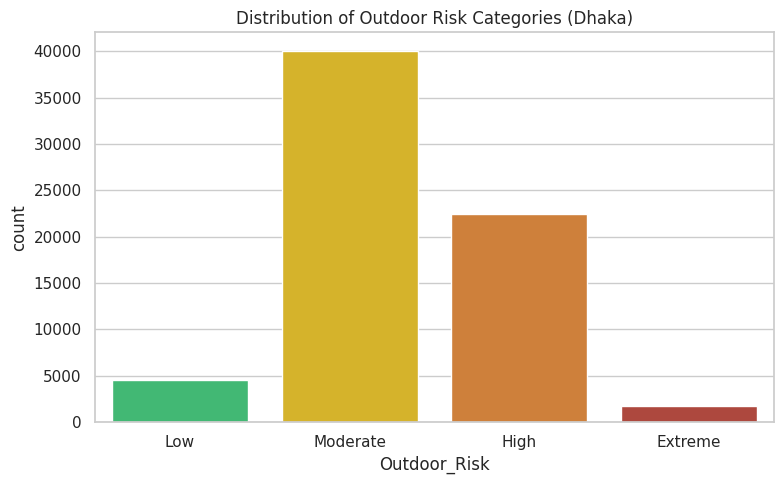

In [30]:
severity_score_map = {
    "Good": 0, "Moderate": 1, "Unhealthy for Sensitive Groups": 2,
    "Unhealthy": 3, "Very Unhealthy": 4, "Hazardous": 5,
}
df["severity_score"] = df["AQI_severity"].map(severity_score_map)

solar_p75 = df["Solar Rad"].quantile(0.75)

def weather_penalty(row):
    penalty = 0
    if row["Temp_category"] == "Hot":
        penalty += 1
    if row["Humidity_category"] in ("High", "Very High"):
        penalty += 1
    if row["Solar Rad"] > solar_p75:
        penalty += 1
    return penalty

df["weather_penalty"] = df.apply(weather_penalty, axis=1)
df["risk_score"] = df["severity_score"] + df["weather_penalty"]

def risk_bucket(score):
    if score <= 1:
        return "Low"
    elif score <= 3:
        return "Moderate"
    elif score <= 5:
        return "High"
    else:
        return "Extreme"

df["Outdoor_Risk"] = df["risk_score"].apply(risk_bucket)

risk_order = ["Low", "Moderate", "High", "Extreme"]
print(df["Outdoor_Risk"].value_counts()[risk_order])

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x="Outdoor_Risk", order=risk_order, palette=["#2ecc71", "#f1c40f", "#e67e22", "#c0392b"], ax=ax)
ax.set_title("Distribution of Outdoor Risk Categories (Dhaka)")
plt.tight_layout()
plt.show()

## 7. Finding the Safest Outdoor Periods

For each hour of the day, we average the `risk_score` (lower = safer) along with AQI, temperature, humidity, and
solar radiation, to spot hours that are comparatively good for outdoor activity across all of these dimensions.

      avg_risk_score  avg_AQI  avg_Temperature  avg_RH  avg_SolarRad
Hour                                                                
17              2.45   113.98            26.40   56.87        228.53
18              2.48   116.21            26.16   59.83        187.57
19              2.74   126.61            25.74   62.48        172.27
16              2.77   115.46            26.80   55.20        298.20
15              2.96   117.29            27.28   54.63        367.53
20              2.98   138.24            25.46   64.36        169.72
14              3.06   119.36            27.44   54.92        411.47
5               3.06   134.10            24.06   73.34        165.53
6               3.07   134.33            23.99   73.76        167.79
4               3.09   136.01            24.20   72.79        167.20
21              3.11   144.30            25.23   65.68        168.68
3               3.12   138.63            24.31   72.13        165.75
7               3.13   136.03     

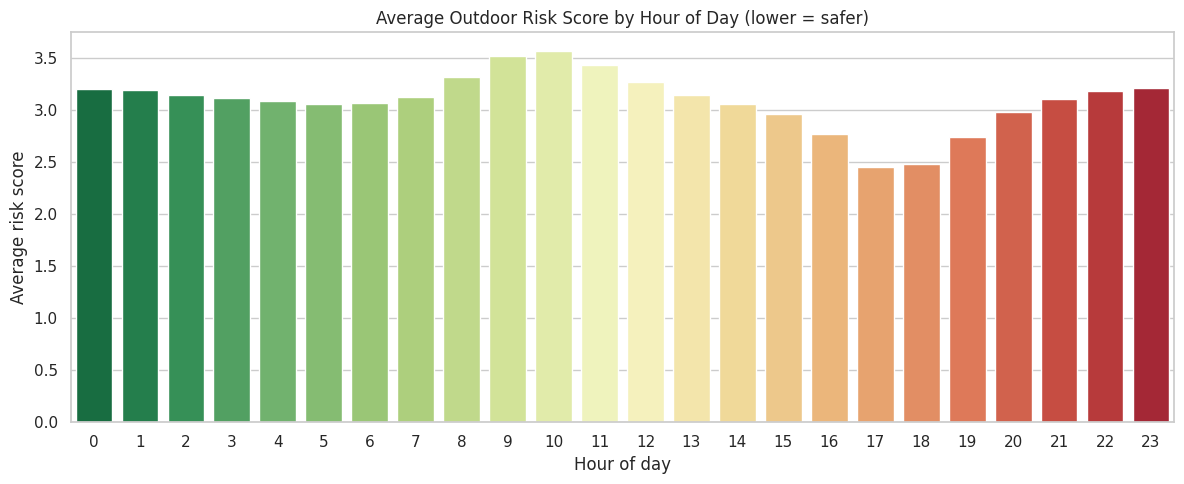


✅ Safest hours (lowest average risk):
      avg_risk_score  avg_AQI  avg_Temperature  avg_RH  avg_SolarRad
Hour                                                                
17              2.45   113.98            26.40   56.87        228.53
18              2.48   116.21            26.16   59.83        187.57
19              2.74   126.61            25.74   62.48        172.27
16              2.77   115.46            26.80   55.20        298.20
15              2.96   117.29            27.28   54.63        367.53

⚠️ Riskiest hours (highest average risk):
      avg_risk_score  avg_AQI  avg_Temperature  avg_RH  avg_SolarRad
Hour                                                                
12              3.27   126.94            26.95   57.59        431.46
8               3.32   140.46            24.61   71.67        233.81
11              3.43   134.00            26.49   60.12        414.67
9               3.52   143.29            25.26   67.76        296.79
10              3.57 

In [31]:
hourly_profile = df.groupby("Hour").agg(
    avg_risk_score=("risk_score", "mean"),
    avg_AQI=("AQI", "mean"),
    avg_Temperature=("Temperature", "mean"),
    avg_RH=("RH", "mean"),
    avg_SolarRad=("Solar Rad", "mean"),
).round(2)

hourly_profile_sorted = hourly_profile.sort_values("avg_risk_score")
print(hourly_profile_sorted)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(x=hourly_profile.index, y=hourly_profile["avg_risk_score"], palette="RdYlGn_r", ax=ax)
ax.set_title("Average Outdoor Risk Score by Hour of Day (lower = safer)")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Average risk score")
plt.tight_layout()
plt.show()

safest_hours = hourly_profile_sorted.head(5)
riskiest_hours = hourly_profile_sorted.tail(5)
print("\n✅ Safest hours (lowest average risk):")
print(safest_hours)
print("\n⚠️ Riskiest hours (highest average risk):")
print(riskiest_hours)

**Recommendation (general outdoor-planning guidance, not medical advice):** the **late afternoon / early evening
hours (roughly 3 PM–8 PM)** tend to combine comparatively lower AQI with manageable temperature and humidity,
making them the best general window for outdoor activity in Dhaka. **Mid-morning hours (around 9 AM–12 PM)** tend
to combine higher pollution with rising heat and sun exposure, and are comparatively less favorable.

## 8. Machine Learning: Forecasting the Next Recorded Period's AQI Severity

The goal now shifts from *describing the past* to *giving advance warning*: can we use present and previous
pollutant/weather measurements to predict what the **next recorded period's** `AQI_severity` will be?

Because a small share of hours are missing (~4% gaps, see section 3.9), consecutive rows are not always exactly
one hour apart. We therefore describe the target as the **"next recorded period"** rather than assuming a fixed
one-hour horizon.

### 8.1 Building the target (with data-leakage prevention in mind)

**Rules we follow to avoid data leakage:**

1. The target is created by **shifting `AQI_severity` one row forward chronologically** (`shift(-1)` after
   sorting by `DateTime`), so each row's target is the severity recorded at the *next available* timestamp.
2. We split the data **chronologically** (train = earlier years, test = the most recent period) — **never** a
   random shuffle-split, since that would let the model "see the future" during training.
3. We **exclude the current row's `AQI` and `AQI_severity`** from the feature set for the genuine
   advance-warning model. Since `AQI_severity` is just a bucketed version of `AQI`, and the *next* severity is
   highly autocorrelated with the *current* one, including it would let the model win almost entirely by
   "memorizing" the current condition rather than genuinely learning from pollutant and weather signals.
   We also exclude `Outdoor_Risk`, `risk_score`, and `severity_score`, since these are directly derived from
   the target.
4. We **do** allow `Prev_AQI` and `Rolling_AQI_24h` — these summarize *past*, already-observed AQI history
   (not the current reading), which is legitimate information available at prediction time in a real
   early-warning system.

In [32]:
df = df.sort_values("DateTime").reset_index(drop=True)
df["AQI_severity_next"] = df["AQI_severity"].shift(-1)

# drop rows where we can't build a valid target or valid history-based features
model_df = df.dropna(subset=["AQI_severity_next", "Prev_AQI", "Rolling_AQI_24h"]).copy()
print("Rows available for modeling:", model_df.shape[0])
print(model_df["AQI_severity_next"].value_counts())

Rows available for modeling: 68633
AQI_severity_next
Moderate                          20675
Unhealthy for Sensitive Groups    18826
Unhealthy                         15219
Very Unhealthy                     8032
Good                               4204
Hazardous                          1677
Name: count, dtype: int64


### 8.2 Feature set

In [33]:
numeric_features = [
    "SO2", "NO", "NO2", "NOX", "CO", "O3", "PM2.5", "PM10",          # current pollutant readings
    "Temperature", "RH", "Solar Rad",                                  # current weather readings
    "Prev_AQI", "Rolling_AQI_24h",                                     # past AQI history (not current AQI)
    "Hour", "Month",
]
categorical_features = ["Temp_category", "Humidity_category", "Day_of_week"]
binary_features = ["Is_weekend", "Pollution_spike"]

feature_cols = numeric_features + categorical_features + binary_features
X = model_df[feature_cols]
y = model_df["AQI_severity_next"]

print("Feature columns used:", feature_cols)
print("\nExcluded on purpose (would leak the target): AQI, AQI_severity, Outdoor_Risk, risk_score, severity_score")

Feature columns used: ['SO2', 'NO', 'NO2', 'NOX', 'CO', 'O3', 'PM2.5', 'PM10', 'Temperature', 'RH', 'Solar Rad', 'Prev_AQI', 'Rolling_AQI_24h', 'Hour', 'Month', 'Temp_category', 'Humidity_category', 'Day_of_week', 'Is_weekend', 'Pollution_spike']

Excluded on purpose (would leak the target): AQI, AQI_severity, Outdoor_Risk, risk_score, severity_score


### 8.3 Chronological train/test split

We sort by time and take the **first 80% chronologically as training data**, and the **most recent 20% as the
test set** — this simulates the real situation of training on the past and forecasting the future.

In [34]:
split_idx = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training rows: {len(X_train):,} | spanning {model_df['DateTime'].iloc[0]} -> {model_df['DateTime'].iloc[split_idx - 1]}")
print(f"Test rows:     {len(X_test):,} | spanning {model_df['DateTime'].iloc[split_idx]} -> {model_df['DateTime'].iloc[-1]}")

Training rows: 54,906 | spanning 2012-11-01 07:00:00 -> 2019-05-28 23:00:00
Test rows:     13,727 | spanning 2019-05-29 00:00:00 -> 2020-12-31 23:00:00


## 9. Training Beginner-Friendly Classification Models

We build a `ColumnTransformer` + `Pipeline` so preprocessing (scaling numeric columns, one-hot encoding
categorical columns) is learned **only from the training set** and applied consistently to the test set — another
safeguard against leakage. All classes use `class_weight="balanced"` since the severity classes are imbalanced
(see section 4.6).

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder="passthrough",  # passes the binary_features through unchanged
)

candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=12, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
}

trained_pipelines = {}
predictions = {}

for name, clf in candidate_models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe
    predictions[name] = pipe.predict(X_test)
    print(f"Trained: {name}")

Trained: Logistic Regression


Trained: Decision Tree


Trained: Random Forest


## 10. Evaluating the Models

Because the severity classes are imbalanced (see section 4.6 — `Moderate` and `Unhealthy` dominate, while
`Good` and `Hazardous` are comparatively rare), **overall accuracy can be misleading**: a model could score
well just by favoring the majority classes while doing poorly on rarer, arguably more important classes like
`Hazardous`. We therefore report **macro F1-score** (which treats every class equally) and **class-wise
recall** alongside plain accuracy.

In [36]:
severity_order_full = ["Good", "Moderate", "Unhealthy for Sensitive Groups", "Unhealthy", "Very Unhealthy", "Hazardous"]

summary_rows = []
for name, preds in predictions.items():
    summary_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision (macro)": precision_score(y_test, preds, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test, preds, average="macro", zero_division=0),
        "F1 (macro)": f1_score(y_test, preds, average="macro", zero_division=0),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)
print(summary_df.round(3))

best_model_name = summary_df.iloc[0]["Model"]
print(f"\n🏆 Best-performing model (by macro F1): {best_model_name}")

                 Model  Accuracy  Precision (macro)  Recall (macro)  \
0        Random Forest     0.660              0.642           0.574   
1  Logistic Regression     0.598              0.581           0.612   
2        Decision Tree     0.628              0.573           0.599   

   F1 (macro)  
0       0.584  
1       0.578  
2       0.577  

🏆 Best-performing model (by macro F1): Random Forest


In [37]:
for name, preds in predictions.items():
    print(f"\n===== {name} — full classification report =====")
    print(classification_report(y_test, preds, labels=severity_order_full, zero_division=0))


===== Logistic Regression — full classification report =====
                                precision    recall  f1-score   support

                          Good       0.28      0.72      0.40       806
                      Moderate       0.63      0.52      0.57      4203
Unhealthy for Sensitive Groups       0.57      0.53      0.55      3325
                     Unhealthy       0.70      0.70      0.70      3150
                Very Unhealthy       0.79      0.67      0.73      1961
                     Hazardous       0.51      0.53      0.52       282

                      accuracy                           0.60     13727
                     macro avg       0.58      0.61      0.58     13727
                  weighted avg       0.63      0.60      0.61     13727


===== Decision Tree — full classification report =====
                                precision    recall  f1-score   support

                          Good       0.36      0.61      0.45       806
              

                                precision    recall  f1-score   support

                          Good       0.44      0.53      0.48       806
                      Moderate       0.67      0.71      0.69      4203
Unhealthy for Sensitive Groups       0.60      0.56      0.58      3325
                     Unhealthy       0.72      0.72      0.72      3150
                Very Unhealthy       0.75      0.73      0.74      1961
                     Hazardous       0.68      0.18      0.29       282

                      accuracy                           0.66     13727
                     macro avg       0.64      0.57      0.58     13727
                  weighted avg       0.66      0.66      0.66     13727



### Confusion matrix — best model

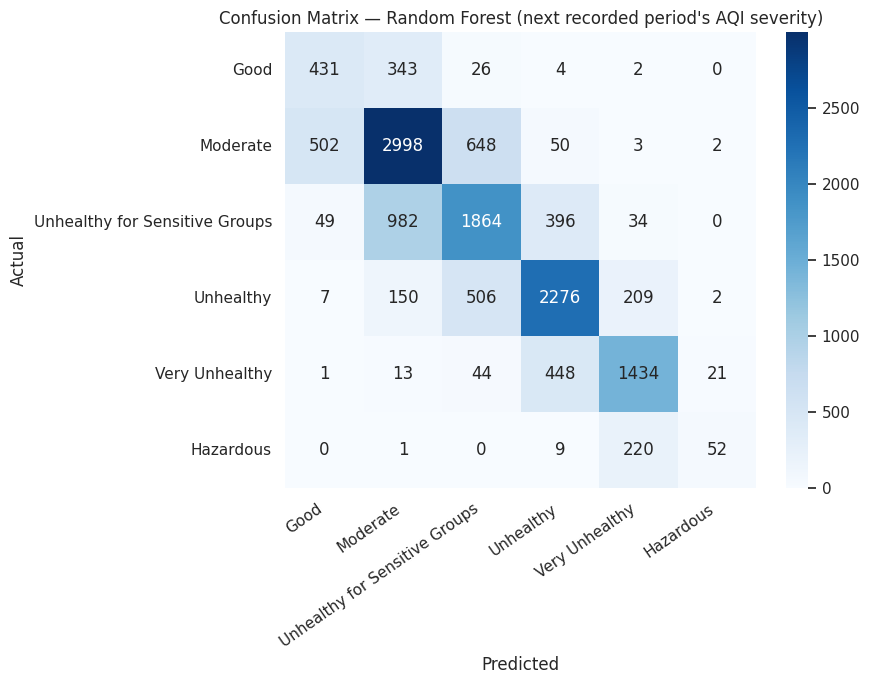

In [38]:
best_preds = predictions[best_model_name]
cm = confusion_matrix(y_test, best_preds, labels=severity_order_full)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=severity_order_full, yticklabels=severity_order_full, ax=ax)
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best_model_name} (next recorded period's AQI severity)")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**How to read this:** most confusion happens **between neighboring severity classes** (e.g. `Unhealthy` mixed up
with `Unhealthy for Sensitive Groups` or `Very Unhealthy`), rather than between very different classes (e.g.
`Good` mistaken for `Hazardous`). This is a reassuring failure pattern for an early-warning tool — the model's
mistakes tend to be "off by one category" rather than wildly wrong.

## 11. Feature Importance — What Drives Future Air Quality?

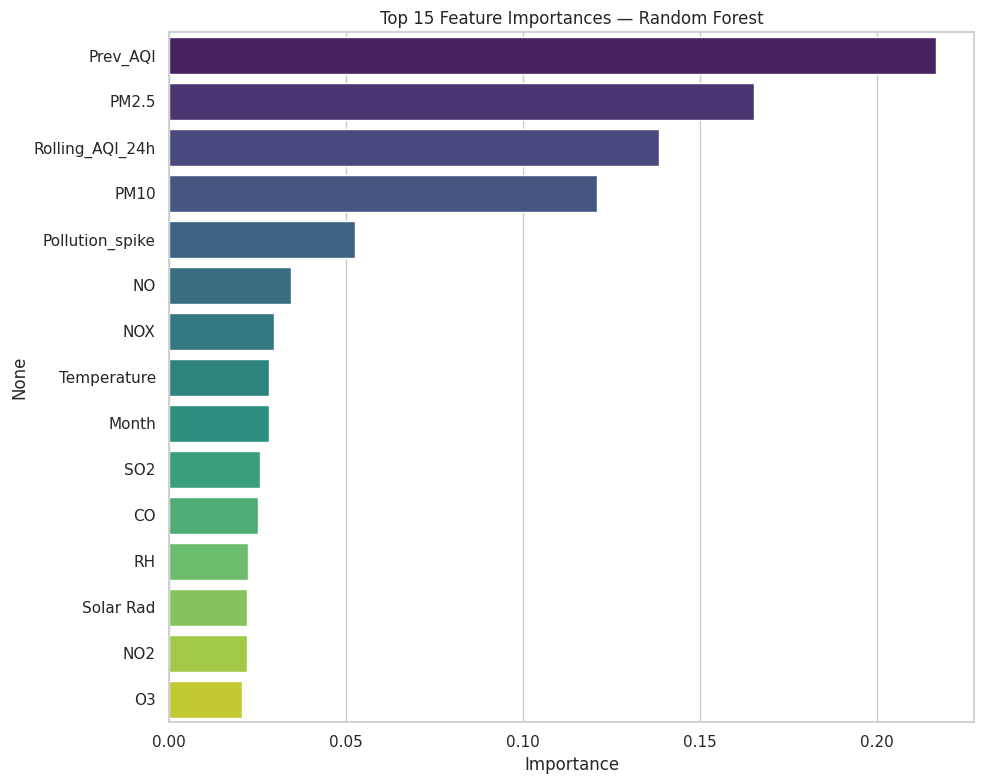

Prev_AQI           0.216501
PM2.5              0.165129
Rolling_AQI_24h    0.138437
PM10               0.120793
Pollution_spike    0.052651
NO                 0.034462
NOX                0.029756
Temperature        0.028323
Month              0.028125
SO2                0.025560
CO                 0.025007
RH                 0.022323
Solar Rad          0.022041
NO2                0.021958
O3                 0.020571
dtype: float64


In [39]:
best_pipeline = trained_pipelines[best_model_name]
ohe = best_pipeline.named_steps["preprocess"].named_transformers_["cat"]
all_feature_names = numeric_features + list(ohe.get_feature_names_out(categorical_features)) + binary_features

fig, ax = plt.subplots(figsize=(10, 8))
best_model = best_pipeline.named_steps["model"]

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=all_feature_names).sort_values(ascending=False)
    top_n = importances.head(15)
    sns.barplot(x=top_n.values, y=top_n.index, palette="viridis", ax=ax)
    ax.set_title(f"Top 15 Feature Importances — {best_model_name}")
    ax.set_xlabel("Importance")
elif hasattr(best_model, "coef_"):
    coef_magnitude = pd.Series(np.abs(best_model.coef_).mean(axis=0), index=all_feature_names).sort_values(ascending=False)
    top_n = coef_magnitude.head(15)
    sns.barplot(x=top_n.values, y=top_n.index, palette="viridis", ax=ax)
    ax.set_title(f"Top 15 Features by Average |Coefficient| — {best_model_name}")
    ax.set_xlabel("Average absolute coefficient (across classes)")

plt.tight_layout()
plt.show()

print(top_n)

**Interpretation:** the model relies most heavily on **recent AQI history** (`Prev_AQI`, `Rolling_AQI_24h`) and
**particulate matter levels** (`PM2.5`, `PM10`) — consistent with the EDA in section 4.4. This makes intuitive
sense: air pollution tends to persist for several hours once it builds up, and particulate matter is the
dominant driver of Dhaka's AQI. Traffic-related gases (`NO`, `NOX`) and weather variables contribute smaller,
but still meaningful, secondary signals.

## 12. Final Findings — In Plain Language

**🕐 Safest and riskiest outdoor hours**
Late afternoon into early evening (roughly **3 PM–8 PM**) tends to offer the best general combination of lower
air pollution and manageable heat/humidity for outdoor activity in Dhaka. Mid-morning hours (roughly **9 AM–12
PM**) tend to be comparatively riskier, combining higher pollution with rising heat and sun exposure.

**🏭 Most influential pollutants**
**PM2.5 and PM10 (particulate matter)** are by far the strongest drivers of Dhaka's AQI, both in the exploratory
correlation analysis and in the predictive model's feature importances. Traffic-related gases (**NO, NOX**) play
a secondary role.

**📅 Important seasonal patterns**
Air quality is strongly seasonal: **winter months (November–February)** are considerably more polluted than the
**monsoon months (June–September)**, most likely due to rain washing pollutants out of the air and seasonal
changes in wind and atmospheric mixing.

**🏆 Best-performing model**
(see the cell below for the actual winner on this run) — the winning model achieved the highest macro F1-score
among the three tested, meaning it did the best job of balancing performance across *all* severity categories —
including the rarer but important `Hazardous` and `Good` classes — rather than only doing well on the most
common categories.

In [40]:
from IPython.display import Markdown, display

display(Markdown(
    f"**🏆 Winning model on this run: `{best_model_name}`** "
    f"— macro F1 = {summary_df.iloc[0]['F1 (macro)']:.3f}, "
    f"accuracy = {summary_df.iloc[0]['Accuracy']:.3f} "
    f"(full comparison table in section 10)."
))

**🏆 Winning model on this run: `Random Forest`** — macro F1 = 0.584, accuracy = 0.660 (full comparison table in section 10).

**⚠️ Model limitations**
- The model is trained on a **single city (Dhaka)** and a specific historical period (2012–2020); it may not
  generalize to other cities or to conditions outside that historical range (e.g. unprecedented pollution events).
- Confusion mostly happens **between adjacent severity categories**, so the model is more reliable at flagging
  "air quality is worsening" broadly than at pinpointing the exact category with certainty.
- The dataset had duplicate timestamps from what appear to be multiple unlabeled monitoring stations, which we
  handled by averaging — a reasonable but imperfect fix given the lack of a station identifier.
- Roughly 4% of hourly timestamps are missing, so "next recorded period" sometimes means more than one hour
  ahead.
- This is a **statistical pattern-recognition tool**, not a certified air-quality forecasting or medical system.

**🧭 Practical outdoor-planning recommendations (general guidance, not medical advice)**
- Favor **late afternoon/early evening hours** for outdoor activity when possible.
- Be extra cautious during **winter months**, especially in the mornings.
- Treat a `High` or `Extreme` Outdoor Risk reading as a signal to shorten outdoor time, choose lower-intensity
  activities, or move activities indoors — particularly for children, older adults, and anyone with respiratory
  or heart conditions.
- Because pollution tends to persist for multiple hours once elevated (per `Prev_AQI`'s importance), a
  noticeably bad AQI reading is a reasonable signal that the next few hours may remain risky too.

## 13. (Optional) Streamlit Dashboard

A simple companion **Streamlit dashboard** (`app.py`, provided alongside this notebook) lets a user:
- Pick a date/hour and view the historical air-quality and weather trends around it,
- See the model's predicted `AQI_severity` for the next recorded period,
- See the corresponding `Outdoor_Risk` category, and
- Look up the safest outdoor hours found in section 7.

Kaggle notebooks don't run interactive Streamlit apps directly, so this piece is meant to be run locally or
deployed separately (e.g. on Streamlit Community Cloud) with:
```bash
pip install streamlit scikit-learn pandas numpy
streamlit run app.py
```